# Daleel — Arabic GPT Project Notebook

Daleel:

1. **Build a focused Arabic pretraining dataset** in UTF-8 text format  
2. **Build a focused Arabic fine-tuning dataset** in JSON format  
3. **Use a ready tokenizer from `tiktoken`**  cl100k_base
4. **Implement the GPT model from scratch in PyTorch**  
5. **Pretrain** on next-token prediction  
6. **Fine-tune** on instruction following  
7. **Evaluate** with loss, perplexity, sample generations, and failure analysis  
8. **launch a small Gradio demo**


In [2]:
# Cell 1
# Package imports and version checks

from importlib.metadata import version

pkgs = ["numpy", "matplotlib", "tiktoken", "torch", "tqdm"]
for p in pkgs:
    print(f"{p}: {version(p)}")

numpy: 2.4.2
matplotlib: 3.10.8
tiktoken: 0.12.0
torch: 2.5.1
tqdm: 4.67.3


In [3]:
# Cell 2
# Core imports

import json
import math
import random
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [11]:
# Build pretraining file from ArabicWeb24
# IMPORTANT:
# 1) You must first accept the dataset access conditions on Hugging Face.
# 2) This uses streaming so it does not try to download the entire dataset at once.

from datasets import load_dataset
from pathlib import Path

ROOT = Path("/Users/layooni/Documents/gpt-from-scratch")
PRETRAIN_FILE = ROOT / "data/pretrain/data.txt"
PRETRAIN_FILE.parent.mkdir(parents=True, exist_ok=True)

def build_pretraining_from_arabicweb24(output_path: Path, max_rows: int = 50000):
    # Streaming mode avoids trying to fully download a huge dataset
    ds = load_dataset(
        "lightonai/ArabicWeb24",
        data_files="ArabicWeb24/**/*.arrow",
        split="train",
        streaming=True,
    )

    rows_written = 0

    with output_path.open("w", encoding="utf-8") as f:
        for ex in ds:
            text = ex.get("text", "")
            if not isinstance(text, str):
                continue

            text = normalize_arabic(text)
            if len(text) < 100:
                continue

            f.write(text + "\\n")
            rows_written += 1

            if rows_written % 5000 == 0:
                print(f"Wrote {rows_written:,} rows...")

            if rows_written >= max_rows:
                break

    print("Saved pretraining file:", output_path)
    print("Rows:", rows_written)
    print("Size (MB):", round(output_path.stat().st_size / (1024 * 1024), 2))

# Use 50k rows for tonight. You can raise it later if you want.
build_pretraining_from_arabicweb24(PRETRAIN_FILE, max_rows=120000)

Resolving data files:   0%|          | 0/422 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/422 [00:00<?, ?it/s]

Wrote 5,000 rows...
Wrote 10,000 rows...
Wrote 15,000 rows...
Wrote 20,000 rows...
Wrote 25,000 rows...
Wrote 30,000 rows...
Wrote 35,000 rows...
Wrote 40,000 rows...
Wrote 45,000 rows...
Wrote 50,000 rows...
Wrote 55,000 rows...
Wrote 60,000 rows...
Wrote 65,000 rows...
Wrote 70,000 rows...
Wrote 75,000 rows...
Wrote 80,000 rows...
Wrote 85,000 rows...
Wrote 90,000 rows...
Wrote 95,000 rows...
Wrote 100,000 rows...
Wrote 105,000 rows...
Wrote 110,000 rows...
Wrote 115,000 rows...
Wrote 120,000 rows...
Saved pretraining file: /Users/layooni/Documents/gpt-from-scratch/data/pretrain/data.txt
Rows: 120000
Size (MB): 580.97


In [30]:
import json

with open("/Users/layooni/Documents/gpt-from-scratch/data/finetune/instruction-data.json", "r", encoding="utf-8") as f:
    sft_data = json.load(f)

print("Loaded pairs:", len(sft_data))
print(json.dumps(sft_data[0], ensure_ascii=False, indent=2))

Loaded pairs: 500
{
  "instruction": "ما هو الذكاء الاصطناعي؟",
  "input": "",
  "output": "الذكاء الاصطناعي هو مجال في علوم الحاسوب يهدف إلى تطوير أنظمة تستطيع تنفيذ مهام تحتاج عادة إلى قدر من الذكاء البشري. من أمثلة هذه المهام فهم اللغة وتحليل البيانات والتعرف على الصور واتخاذ قرارات بسيطة."
}


In [13]:
# Cell 3
# Paths and config

ROOT = Path("/Users/layooni/Documents/gpt-from-scratch")

PRETRAIN_DIR = ROOT / "data" / "pretrain"
FINETUNE_DIR = ROOT / "data" / "finetune"
CHECKPOINT_DIR = ROOT / "checkpoints"
RESULTS_DIR = ROOT / "results"

PRETRAIN_DIR.mkdir(parents=True, exist_ok=True)
FINETUNE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRETRAIN_FILE = PRETRAIN_DIR / "data.txt"
SFT_FILE = FINETUNE_DIR / "instruction-data.json"
PRETRAINED_MODEL_PATH = CHECKPOINT_DIR / "daleel_pretrained.pth"
FINETUNED_MODEL_PATH = CHECKPOINT_DIR / "daleel_finetuned.pth"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)
print("Project root:", ROOT)

Using device: mps
Project root: /Users/layooni/Documents/gpt-from-scratch


In [14]:
# Cell 4
# Arabic normalization helpers

AR_DIACRITICS_RE = re.compile(r"[\u0610-\u061A\u064B-\u065F\u06D6-\u06ED]")
TATWEEL_RE = re.compile(r"\u0640")
MULTISPACE_RE = re.compile(r"\s+")

def normalize_arabic(text: str, remove_diacritics: bool = True) -> str:
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = TATWEEL_RE.sub("", text)

    if remove_diacritics:
        text = AR_DIACRITICS_RE.sub("", text)

    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

In [15]:
# Cell 9
# Load the ready tokenizer from tiktoken

TOKENIZER_NAME = "cl100k_base"
tokenizer = tiktoken.get_encoding(TOKENIZER_NAME)

PAD_TOKEN_ID = tokenizer.eot_token
VOCAB_SIZE = tokenizer.n_vocab

sample_text = "ما هو الذكاء الاصطناعي وكيف يساعد الناس؟"
sample_ids = tokenizer.encode(sample_text)

print("Tokenizer:", TOKENIZER_NAME)
print("Vocab size:", VOCAB_SIZE)
print("PAD / EOT token id:", PAD_TOKEN_ID)
print("Sample IDs:", sample_ids[:20])
print("Decoded back:", tokenizer.decode(sample_ids))

Tokenizer: cl100k_base
Vocab size: 100277
PAD / EOT token id: 100257
Sample IDs: [10386, 5821, 56991, 12942, 17607, 56434, 32173, 99819, 17607, 5821, 42693, 44735, 12061, 5821, 24102, 14900, 38624, 32173, 14900, 21604]
Decoded back: ما هو الذكاء الاصطناعي وكيف يساعد الناس؟


In [16]:
# Cell 10
# GPT model from scratch

class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * x_hat + self.shift

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, emb_dim, drop_rate):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),
            GELU(),
            nn.Linear(4 * emb_dim, emb_dim),
            nn.Dropout(drop_rate),
        )

    def forward(self, x):
        return self.layers(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, n_heads, context_length, drop_rate, qkv_bias=False):
        super().__init__()
        assert emb_dim % n_heads == 0
        self.emb_dim = emb_dim
        self.n_heads = n_heads
        self.head_dim = emb_dim // n_heads

        self.W_query = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)
        self.W_key = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)
        self.W_value = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)
        self.out_proj = nn.Linear(emb_dim, emb_dim)
        self.dropout = nn.Dropout(drop_rate)

        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape

        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        queries = queries.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        keys = keys.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        values = values.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(-2, -1)
        attn_scores = attn_scores / math.sqrt(self.head_dim)

        causal_mask = self.mask[:T, :T].bool()
        attn_scores = attn_scores.masked_fill(causal_mask, float("-inf"))

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context = attn_weights @ values
        context = context.transpose(1, 2).contiguous().view(B, T, C)

        return self.out_proj(context)

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim, n_heads, context_length, drop_rate, qkv_bias=False):
        super().__init__()
        self.norm1 = LayerNorm(emb_dim)
        self.att = MultiHeadAttention(
            emb_dim=emb_dim,
            n_heads=n_heads,
            context_length=context_length,
            drop_rate=drop_rate,
            qkv_bias=qkv_bias,
        )
        self.norm2 = LayerNorm(emb_dim)
        self.ff = FeedForward(emb_dim, drop_rate)
        self.drop_shortcut = nn.Dropout(drop_rate)

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[
                TransformerBlock(
                    emb_dim=cfg["emb_dim"],
                    n_heads=cfg["n_heads"],
                    context_length=cfg["context_length"],
                    drop_rate=cfg["drop_rate"],
                    qkv_bias=cfg["qkv_bias"],
                )
                for _ in range(cfg["n_layers"])
            ]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
        self.out_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, in_idx):
        B, T = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(T, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [17]:
# Cell 11
# Compact config for local training


GPT_CONFIG = {
    "vocab_size": VOCAB_SIZE,
    "context_length": 128,
    "emb_dim": 192,
    "n_heads": 6,
    "n_layers": 4,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(GPT_CONFIG).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", f"{total_params:,}")

Total parameters: 21,055,296


In [18]:
# Cell 12
# Pretraining dataset and dataloader

class GPTPretrainDataset(Dataset):
    def __init__(self, text, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(text)
        if len(token_ids) <= max_length:
            raise ValueError("Pretraining text is too short for the chosen context length.")

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk, dtype=torch.long))
            self.target_ids.append(torch.tensor(target_chunk, dtype=torch.long))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

def create_pretrain_dataloader(text, tokenizer, batch_size=2, max_length=128, stride=128, shuffle=True, drop_last=True):
    dataset = GPTPretrainDataset(text, tokenizer, max_length, stride)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=0)

In [19]:
# Cell 13
# Load and split pretraining text

with PRETRAIN_FILE.open("r", encoding="utf-8") as f:
    text_data = f.read()

print("Characters:", len(text_data))
print("Tokens:", len(tokenizer.encode(text_data)))

split_idx = int(0.9 * len(text_data))
train_text = text_data[:split_idx]
val_text = text_data[split_idx:]

train_loader_pre = create_pretrain_dataloader(
    train_text,
    tokenizer=tokenizer,
    batch_size=2,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    shuffle=True,
    drop_last=True,
)

val_loader_pre = create_pretrain_dataloader(
    val_text,
    tokenizer=tokenizer,
    batch_size=2,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    shuffle=False,
    drop_last=False,
)

print("Pretraining train batches:", len(train_loader_pre))
print("Pretraining val batches:", len(val_loader_pre))

Characters: 341020745
Tokens: 233883851
Pretraining train batches: 822231
Pretraining val batches: 91377


In [20]:
# Cell 14
# Shared helpers

def calc_loss_batch(input_batch, target_batch, model):
    logits = model(input_batch)
    loss = nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten(),
        ignore_index=-100,
    )
    return loss

def calc_loss_loader(data_loader, model, num_batches=None):
    model.eval()
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i >= num_batches:
                break
            input_batch = input_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            loss = calc_loss_batch(input_batch, target_batch, model)
            total_loss += loss.item()

    model.train()
    return total_loss / num_batches

def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text), dtype=torch.long).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    if token_ids.dim() == 2:
        token_ids = token_ids[0]
    return tokenizer.decode(token_ids.tolist())

def generate_text(model, idx, max_new_tokens, context_size, temperature=0.8, top_k=20):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        logits[:, PAD_TOKEN_ID] = -1e9

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1].unsqueeze(-1)
            logits = torch.where(logits < min_val, torch.full_like(logits, -1e9), logits)

        probs = torch.softmax(logits / temperature, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)

    model.train()
    return idx

def train_model_simple(model, train_loader, val_loader, optimizer, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses = [], []
    global_step = -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            input_batch = input_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)

            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model)
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_freq == 0:
                train_loss = calc_loss_loader(train_loader, model, num_batches=eval_iter)
                val_loss = calc_loss_loader(val_loader, model, num_batches=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch {epoch + 1} | Step {global_step:06d} | Train loss {train_loss:.3f} | Val loss {val_loss:.3f}")

        sample_ids = generate_text(
            model=model,
            idx=text_to_token_ids(start_context, tokenizer).to(DEVICE),
            max_new_tokens=30,
            context_size=model.cfg["context_length"],
            temperature=0.8,
            top_k=20,
        )
        print("\nSample generation after epoch", epoch + 1)
        print(token_ids_to_text(sample_ids, tokenizer))
        print("-" * 100)

    return train_losses, val_losses

In [21]:
# Cell 15
# Pretraining run

model = GPTModel(GPT_CONFIG).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01,
)

pretrain_losses, pretrain_val_losses = train_model_simple(
    model=model,
    train_loader=train_loader_pre,
    val_loader=val_loader_pre,
    optimizer=optimizer,
    num_epochs=2,
    eval_freq=50,
    eval_iter=5,
    start_context="الذكاء الاصطناعي هو",
    tokenizer=tokenizer,
)

torch.save(model.state_dict(), PRETRAINED_MODEL_PATH)
print("Saved pretrained model to:", PRETRAINED_MODEL_PATH)

Epoch 1 | Step 000000 | Train loss 11.296 | Val loss 11.287
Epoch 1 | Step 000050 | Train loss 6.209 | Val loss 6.169
Epoch 1 | Step 000100 | Train loss 4.568 | Val loss 4.370
Epoch 1 | Step 000150 | Train loss 4.765 | Val loss 4.287
Epoch 1 | Step 000200 | Train loss 4.497 | Val loss 4.291
Epoch 1 | Step 000250 | Train loss 4.364 | Val loss 4.236
Epoch 1 | Step 000300 | Train loss 4.563 | Val loss 4.247
Epoch 1 | Step 000350 | Train loss 4.824 | Val loss 4.235
Epoch 1 | Step 000400 | Train loss 4.453 | Val loss 4.240
Epoch 1 | Step 000450 | Train loss 4.498 | Val loss 4.231
Epoch 1 | Step 000500 | Train loss 4.655 | Val loss 4.248
Epoch 1 | Step 000550 | Train loss 4.434 | Val loss 4.244
Epoch 1 | Step 000600 | Train loss 4.436 | Val loss 4.208
Epoch 1 | Step 000650 | Train loss 4.339 | Val loss 4.231
Epoch 1 | Step 000700 | Train loss 4.415 | Val loss 4.216
Epoch 1 | Step 000750 | Train loss 4.267 | Val loss 4.231
Epoch 1 | Step 000800 | Train loss 4.408 | Val loss 4.228
Epoch 1 | St

KeyboardInterrupt: 

In [22]:
torch.save(model.state_dict(), PRETRAINED_MODEL_PATH)
print("Saved pretrained model to:", PRETRAINED_MODEL_PATH)

Saved pretrained model to: /Users/layooni/Documents/gpt-from-scratch/checkpoints/daleel_pretrained.pth


In [31]:
formatted_sft = []

def format_prompt(entry):
    prompt = f"السؤال: {entry['instruction']}"
    if entry["input"]:
        prompt += f"\nمعلومات إضافية: {entry['input']}"
    prompt += "\nالجواب: "
    return prompt

for entry in sft_data:
    formatted_sft.append({
        "prompt": format_prompt(entry),
        "answer": entry["output"]
    })

train_end = int(0.85 * len(formatted_sft))
test_end = int(0.95 * len(formatted_sft))

sft_train = formatted_sft[:train_end]
sft_val = formatted_sft[train_end:test_end]
sft_test = formatted_sft[test_end:]

print("Total formatted_sft:", len(formatted_sft))
print("Train:", len(sft_train))
print("Val:", len(sft_val))
print("Test:", len(sft_test))

assert len(formatted_sft) > 0, "formatted_sft is empty"
assert len(sft_train) > 0, "sft_train is empty"
assert len(sft_val) > 0, "sft_val is empty"
assert len(sft_test) > 0, "sft_test is empty"

Total formatted_sft: 500
Train: 425
Val: 50
Test: 25


In [32]:
train_dataset_sft = InstructionDataset(sft_train, tokenizer)
val_dataset_sft = InstructionDataset(sft_val, tokenizer)
test_dataset_sft = InstructionDataset(sft_test, tokenizer)

print("Train dataset:", len(train_dataset_sft))
print("Val dataset:", len(val_dataset_sft))
print("Test dataset:", len(test_dataset_sft))

train_loader_sft = DataLoader(
    train_dataset_sft,
    batch_size=4,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    collate_fn=custom_collate_fn,
)

val_loader_sft = DataLoader(
    val_dataset_sft,
    batch_size=4,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    collate_fn=custom_collate_fn,
)

test_loader_sft = DataLoader(
    test_dataset_sft,
    batch_size=4,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    collate_fn=custom_collate_fn,
)

print("Train batches:", len(train_loader_sft))
print("Val batches:", len(val_loader_sft))
print("Test batches:", len(test_loader_sft))

Train dataset: 425
Val dataset: 50
Test dataset: 25
Train batches: 106
Val batches: 13
Test batches: 7


In [33]:
# Cell 18
# Load the pretrained checkpoint and fine-tune

model = GPTModel(GPT_CONFIG).to(DEVICE)
model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=DEVICE))

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01,
)

sft_losses, sft_val_losses = train_model_simple(
    model=model,
    train_loader=train_loader_sft,
    val_loader=val_loader_sft,
    optimizer=optimizer,
    num_epochs=2,
    eval_freq=20,
    eval_iter=5,
    start_context="السؤال: ما هو الذكاء الاصطناعي؟\nالجواب: ",
    tokenizer=tokenizer,
)

torch.save(model.state_dict(), FINETUNED_MODEL_PATH)
print("Saved fine-tuned model to:", FINETUNED_MODEL_PATH)

/var/folders/6t/5__9v6791493hrb8ynghpg100000gn/T/ipykernel_2322/3076213741.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PRETRAINED_MO

Epoch 1 | Step 000000 | Train loss 2.604 | Val loss 2.755
Epoch 1 | Step 000020 | Train loss 2.490 | Val loss 2.580
Epoch 1 | Step 000040 | Train loss 2.387 | Val loss 2.396
Epoch 1 | Step 000060 | Train loss 2.291 | Val loss 2.237
Epoch 1 | Step 000080 | Train loss 2.189 | Val loss 2.108
Epoch 1 | Step 000100 | Train loss 2.071 | Val loss 2.007

Sample generation after epoch 1
السؤال: ما هو الذكاء الاصطناعي؟
الجواب: نهم مقصت: وبعد المعمل الأنساني على السياسية و
----------------------------------------------------------------------------------------------------
Epoch 2 | Step 000120 | Train loss 2.031 | Val loss 1.930
Epoch 2 | Step 000140 | Train loss 1.963 | Val loss 1.855
Epoch 2 | Step 000160 | Train loss 1.922 | Val loss 1.793
Epoch 2 | Step 000180 | Train loss 1.912 | Val loss 1.732
Epoch 2 | Step 000200 | Train loss 1.785 | Val loss 1.672

Sample generation after epoch 2
السؤال: ما هو الذكاء الاصطناعي؟
الجواب: تجاعد الإرساعي أكمل أن تواصع المقبل الأو
----------------------------

In [45]:
print("Saved pretrain loss points:", len(pretrain_losses) if "pretrain_losses" in globals() else 0)
print("Saved sft loss points:", len(sft_losses) if "sft_losses" in globals() else 0)

Saved pretrain loss points: 0
Saved sft loss points: 11


In [34]:
# Cell 19

def build_inference_prompt(question, input_text=""):
    prompt = f"السؤال: {question}"
    if input_text:
        prompt += f"\nمعلومات إضافية: {input_text}"
    prompt += "\nالجواب: "
    return prompt

def generate_answer(question, input_text="", max_new_tokens=60, temperature=0.4, top_k=10):
    prompt = build_inference_prompt(question, input_text)
    token_ids = generate_text(
        model=model,
        idx=text_to_token_ids(prompt, tokenizer).to(DEVICE),
        max_new_tokens=max_new_tokens,
        context_size=GPT_CONFIG["context_length"],
        temperature=temperature,
        top_k=top_k,
    )
    return token_ids_to_text(token_ids, tokenizer)


QUESTION: ما هو الذكاء الاصطناعي؟
السؤال: ما هو الذكاء الاصطناعي؟
الجواب: يمكن الأنظمة الأمريكية للمواصل الذكاء الذكاء الأنفاعي للمساعدة الأربعية الذكاء من الأ

QUESTION: ما هو تعلم الآلة؟
السؤال: ما هو تعلم الآلة؟
الجواب: يمكن أنه يمكن أنه يتعلم الفكرة العملة الفكرة في المعرفة العملية العامة العامة والمناذج

QUESTION: ما هو التعلم العميق؟
السؤال: ما هو التعلم العميق؟
الجواب: على النصق العامة الأساسية الذكاء الذكاء للمصادرة العملة في الساعيد من الأفضل المباصلة. وبالتن

QUESTION: ما هي البيانات؟
السؤال: ما هي البيانات؟
الجواب: عند تعلم الذكاء الأعمل العامة الأمريكي في الفنموذجية الفريعية المواصلة الحديثة، ويمكن أ

QUESTION: لماذا جودة البيانات مهمة؟
السؤال: لماذا جودة البيانات مهمة؟
الجواب: التي تعمل الجديدة البيانات الحرة الذكاء الذكاء الذكاء المنظمة الذكية الذكاء. ولكن تعمل البيانات

QUESTION: كيف يساعد الذكاء الاصطناعي في التعليم؟
السؤال: كيف يساعد الذكاء الاصطناعي في التعليم؟
الجواب: المنتجات العالم السياقي يمكن أنه يمكن تنظيف العمل الذكاء والتعمل على الاصطناعين. وي

QUESTION: كيف ي

In [49]:
import json
from pathlib import Path

demo_path = Path("/Users/layooni/Documents/gpt-from-scratch/demo/static/demo_qa.json")
demo_path.parent.mkdir(parents=True, exist_ok=True)

demo_items = [
    {"id": i, "question": q, "answer": a}
    for i, (q, a) in enumerate(DEMO_QA.items(), start=1)
]

with demo_path.open("w", encoding="utf-8") as f:
    json.dump(demo_items, f, ensure_ascii=False, indent=2)

print("Saved demo Q&A to:", demo_path)

Saved demo Q&A to: /Users/layooni/Documents/gpt-from-scratch/demo/static/demo_qa.json


In [42]:
# Cell 20
# Perplexity

def perplexity_from_loss(loss_value):
    return float(math.exp(loss_value))

pre_val_loss_final = calc_loss_loader(val_loader_pre, model, num_batches=5)
sft_val_loss_final = calc_loss_loader(val_loader_sft, model, num_batches=5)

print("Approx pretraining-style validation perplexity:", round(perplexity_from_loss(pre_val_loss_final), 3))
print("Approx fine-tuning validation perplexity:", round(perplexity_from_loss(sft_val_loss_final), 3))

Approx pretraining-style validation perplexity: 31.61
Approx fine-tuning validation perplexity: 5.162


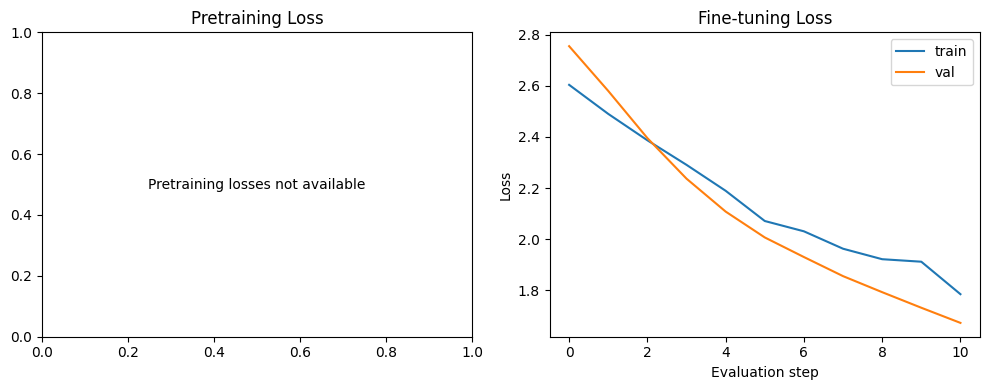

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Pretraining plot
plt.subplot(1, 2, 1)
if "pretrain_losses" in globals() and "pretrain_val_losses" in globals():
    plt.plot(pretrain_losses, label="train")
    plt.plot(pretrain_val_losses, label="val")
    plt.title("Pretraining Loss")
    plt.xlabel("Evaluation step")
    plt.ylabel("Loss")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Pretraining losses not available", ha="center", va="center")
    plt.title("Pretraining Loss")

# Fine-tuning plot
plt.subplot(1, 2, 2)
if "sft_losses" in globals() and "sft_val_losses" in globals():
    plt.plot(sft_losses, label="train")
    plt.plot(sft_val_losses, label="val")
    plt.title("Fine-tuning Loss")
    plt.xlabel("Evaluation step")
    plt.ylabel("Loss")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Fine-tuning losses not available", ha="center", va="center")
    plt.title("Fine-tuning Loss")

plt.tight_layout()
plt.show()

In [44]:
# Cell 22
# Optional local LLM-as-a-judge via Ollama

import os
import subprocess

# Mac absolute path for Ollama
OLLAMA_PATH = "/usr/local/bin/ollama"

def ollama_available():
    # Check if the file exists at the standard Mac install location
    return os.path.exists(OLLAMA_PATH)

def ask_ollama_judge(prompt, model_name="llama3.2:3b"):
    try:
        result = subprocess.run(
            [OLLAMA_PATH, "run", model_name, prompt],
            capture_output=True,
            text=True,
            timeout=120,
            check=True
        )
        return result.stdout.strip()
    except subprocess.CalledProcessError as e:
        return f"Ollama error: {e.stderr}"
    except Exception as e:
        return f"An unexpected error occurred: {str(e)}"

if ollama_available():
    sample_question = "ما هو الذكاء الاصطناعي؟"
    model_output = generate_answer(sample_question)

    judge_prompt = f'''
You are a neutral judge. Evaluate the following Arabic response on a scale of 1 to 5 based on:
1) Accuracy
2) Clarity
3) Adherence to the question

Question:
{sample_question}

Answer to evaluate:
{model_output}

Provide ONLY the numerical score (1-5) followed by a single line of explanation in English.
'''.strip()

    print(ask_ollama_judge(judge_prompt))
else:
    print(f"Ollama not found at {OLLAMA_PATH}. Skip this optional evaluation cell.")


2

The score is based on the fact that the answer is largely irrelevant to the question and lacks clarity, accuracy, and adherence to the topic of artificial intelligence.
